In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams
random_state = 42
import autoreload
%load_ext autoreload
%autoreload 2
import python_code.Scripts as sc
import python_code.Reference as ref
import pickle

from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,precision_score
from treeinterpreter import treeinterpreter as ti
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier,BaggingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [2]:
df = pd.read_csv("./data/final.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 33 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   RAWNET    3904 non-null   float64
 1   FSSLTDE2  3904 non-null   float64
 2   FSGA      3904 non-null   float64
 3   FSTANF    3904 non-null   float64
 4   FSASSET   3904 non-null   float64
 5   FSSSI     3904 non-null   float64
 6   FSNONCIT  3904 non-null   float64
 7   FSSTDDE2  3904 non-null   float64
 8   SHELDED   3904 non-null   float64
 9   REALPROP  3904 non-null   float64
 10  TANF_IND  3904 non-null   float64
 11  HWGT      3904 non-null   float64
 12  RAWERND   3904 non-null   float64
 13  WRK_POOR  3904 non-null   float64
 14  FSERNDED  3904 non-null   float64
 15  FSUNEARN  3904 non-null   float64
 16  FSNETINC  3904 non-null   float64
 17  TPOV      3904 non-null   float64
 18  FSERNDE2  3904 non-null   float64
 19  FSNELDER  3904 non-null   float64
 20  CERTHHSZ  3904 non-null   floa

In [4]:
# Data Prep
X = df.drop(columns = ['CAT_ELIG'])
y = df['CAT_ELIG']

In [5]:
#baseline, NULL Model
y.value_counts(normalize=True)

1.0    0.662398
0.0    0.337602
Name: CAT_ELIG, dtype: float64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.3,random_state=random_state)

In [7]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [8]:
np.savetxt('./data/TrainTest/X_train.csv',X_train,delimiter=',')
np.savetxt('./data/TrainTest/y_train.csv',y_train,delimiter=',')
np.savetxt('./data/TrainTest/X_test.csv',X_test,delimiter=',')
np.savetxt('./data/TrainTest/y_test.csv',y_test,delimiter=',')

In [9]:
pca = PCA(n_components=10,random_state=42)
pca.fit(X_train)
X_train_pc = pca.transform(X_train)
X_test_pc = pca.transform(X_test)

In [10]:
# Models Overview
models = {
    'LogReg': LogisticRegression(),
    'Decision Tree':DecisionTreeClassifier(),
    'Random Forest':RandomForestClassifier(),
    'Gradient Boost':GradientBoostingClassifier(),
    'Ada Boost':AdaBoostClassifier(),
    'SVC':SVC(),
    'Naive Bayes':GaussianNB()}

In [11]:
final = pd.DataFrame(columns = ['cross_val_train','cross_val_test','test_recall','test_precision'])
idx=0
while idx < len(models.keys()):
    for name,model in models.items():
        results = {}
        results['name']=name
        name=model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        results['cross_val_train'] = np.mean(cross_val_score(model,X_train,y_train,cv=4))
        results['cross_val_test'] = np.mean(cross_val_score(model,X_test,y_test,cv=4))
        results['test_recall'] = recall_score(y_test, y_pred_test)
        results['test_precision'] = precision_score(y_test, y_pred_test)
        final = final.append(results,ignore_index=True)
        idx+=1

C:\Users\Owner\AppData\Local\Temp\ipykernel_18032\3656336374.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final = final.append(results,ignore_index=True)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18032\3656336374.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final = final.append(results,ignore_index=True)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18032\3656336374.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final = final.append(results,ignore_index=True)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18032\3656336374.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final = final.append(results,ignore_index=Tr

In [12]:
final.set_index('name')

,cross_val_train,cross_val_test,test_recall,test_precision
name,,,,
LogReg,0.884334,0.862628,0.900262,0.903821
Decision Tree,0.907028,0.911263,0.940945,0.947160
Random Forest,0.940703,0.937713,0.964567,0.953307
Gradient Boost,0.941435,0.933447,0.950131,0.961487
Ada Boost,0.922401,0.920648,0.937008,0.939474
SVC,0.884700,0.854949,0.901575,0.928378
Naive Bayes,0.767204,0.741468,0.833333,0.908441


In [13]:
# Adding PCA to data and comparing scores
pc_final = pd.DataFrame(columns = ['cross_val_train','cross_val_test','test_recall','test_precision'])
idx=0
while idx < len(models.keys()):
    for name,model in models.items():
        results = {}
        results['name']=name
        name=model.fit(X_train_pc, y_train)
        y_pred_train = model.predict(X_train_pc)
        y_pred_test = model.predict(X_test_pc)
        results['cross_val_train'] = np.mean(cross_val_score(model,X_train_pc,y_train,cv=4))
        results['cross_val_test'] = np.mean(cross_val_score(model,X_test_pc,y_test,cv=4))
        results['test_recall'] = recall_score(y_test, y_pred_test)
        results['test_precision'] = precision_score(y_test, y_pred_test)
        pc_final = pc_final.append(results,ignore_index=True)
        idx+=1

C:\Users\Owner\AppData\Local\Temp\ipykernel_18032\1784870362.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pc_final = pc_final.append(results,ignore_index=True)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18032\1784870362.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pc_final = pc_final.append(results,ignore_index=True)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18032\1784870362.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pc_final = pc_final.append(results,ignore_index=True)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18032\1784870362.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pc_final = pc_final.append

In [14]:
pc_final.set_index('name')

,cross_val_train,cross_val_test,test_recall,test_precision
name,,,,
LogReg,0.783675,0.763652,0.892388,0.770102
Decision Tree,0.834187,0.802048,0.889764,0.878238
Random Forest,0.890190,0.855802,0.927822,0.897208
Gradient Boost,0.877379,0.860922,0.908136,0.882653
Ada Boost,0.852855,0.846416,0.900262,0.879487
SVC,0.831991,0.834471,0.874016,0.871728
Naive Bayes,0.726940,0.713311,0.958005,0.692600


In [15]:
# Model Selection
for name,model in models.items():
    name = model.fit(X_train,y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(name)
    print(classification_report(y_test, y_pred_test))
    print('\n')

LogisticRegression()
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82       410
         1.0       0.90      0.90      0.90       762

    accuracy                           0.87      1172
   macro avg       0.86      0.86      0.86      1172
weighted avg       0.87      0.87      0.87      1172



DecisionTreeClassifier()
              precision    recall  f1-score   support

         0.0       0.89      0.88      0.89       410
         1.0       0.94      0.94      0.94       762

    accuracy                           0.92      1172
   macro avg       0.91      0.91      0.91      1172
weighted avg       0.92      0.92      0.92      1172



RandomForestClassifier()
              precision    recall  f1-score   support

         0.0       0.93      0.92      0.92       410
         1.0       0.96      0.96      0.96       762

    accuracy                           0.95      1172
   macro avg       0.94      0.94      0.94      1172

In [26]:
# Running Models
rf = RandomForestClassifier()
params={'max_depth':[None,25],
       'max_features':[None,'auto'],
       'n_estimators':[200]}
rf_gs = GridSearchCV(rf,param_grid=params)
rf_gs.fit(X_train,y_train)
print(rf_gs.best_score_)
rf_gs.best_params_

0.943994214195311


{'max_depth': None, 'max_features': 'auto', 'n_estimators': 200}

In [17]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [18]:
instances = X_test[[735]]
instances

array([[-0.88061189, -0.87253073, -0.1335093 , -0.34230342, -0.24309398,
        -0.42833737,  1.78070948, -1.59315573,  1.00652396, -0.03517855,
        -0.36488324, -0.51614194, -0.59885312, -0.76825854, -0.59758589,
        -0.91848291, -0.8826584 , -1.49056789, -0.56404251, -0.40909055,
         1.02614408, -0.55893964,  0.39411313, -1.28640995,  1.02614408,
         1.0459183 , -1.25472977, -0.51403261, -0.59800159, -0.24501332,
        -0.02833014, -0.35352552]])

In [19]:
ft_list = []
prediction, bias, contributions = ti.predict(rf, instances)
print( "Prediction", prediction)
print( "Bias (trainset prior)", bias)
print ("Feature contributions:")
for c, feature in zip(contributions[0], 
                             X.columns):
    ft_list.append((feature, np.round(c, 2)))
    print (feature, c)
    
labels, values = zip(*ft_list)

Prediction [[0.6 0.4]]
Bias (trainset prior) [[0.33270498 0.66729502]]
Feature contributions:
RAWNET [-0.00649703  0.00649703]
FSSLTDE2 [ 0.00142843 -0.00142843]
FSGA [ 0.00098967 -0.00098967]
FSTANF [ 0.02632922 -0.02632922]
FSASSET [-0.0290524  0.0290524]
FSSSI [ 0.01594694 -0.01594694]
FSNONCIT [ 0.02111427 -0.02111427]
FSSTDDE2 [ 0.04125566 -0.04125566]
SHELDED [ 0.11583235 -0.11583235]
REALPROP [0. 0.]
TANF_IND [ 0.01706348 -0.01706348]
HWGT [ 0.06039981 -0.06039981]
RAWERND [-0.01644036  0.01644036]
WRK_POOR [-0.00673776  0.00673776]
FSERNDED [-0.00827824  0.00827824]
FSUNEARN [ 0.0234476 -0.0234476]
FSNETINC [-0.00450715  0.00450715]
TPOV [-0.00241885  0.00241885]
FSERNDE2 [-0.01083202  0.01083202]
FSNELDER [ 0.00078569 -0.00078569]
CERTHHSZ [ 0.00761714 -0.00761714]
FSWAGES [-0.00562436  0.00562436]
FSTOTDED [-0.0169682  0.0169682]
FSTOTDE2 [-0.00658373  0.00658373]
FSUSIZE [-0.00688868  0.00688868]
FSSLTDED [ 0.10726541 -0.10726541]
FSGRINC [-0.00471669  0.00471669]
FSDIS [ 0.

In [20]:
df1 = pd.DataFrame(ft_list,columns=['feature','array'])
df2 = pd.DataFrame(df1["array"].to_list(), columns=['pred_0', 'pred_1'])
coef_df = pd.concat([df1,df2],axis=1).drop(columns=['array'])
coef_df.to_csv('./data/2018_indicators/coef.csv',index=None)

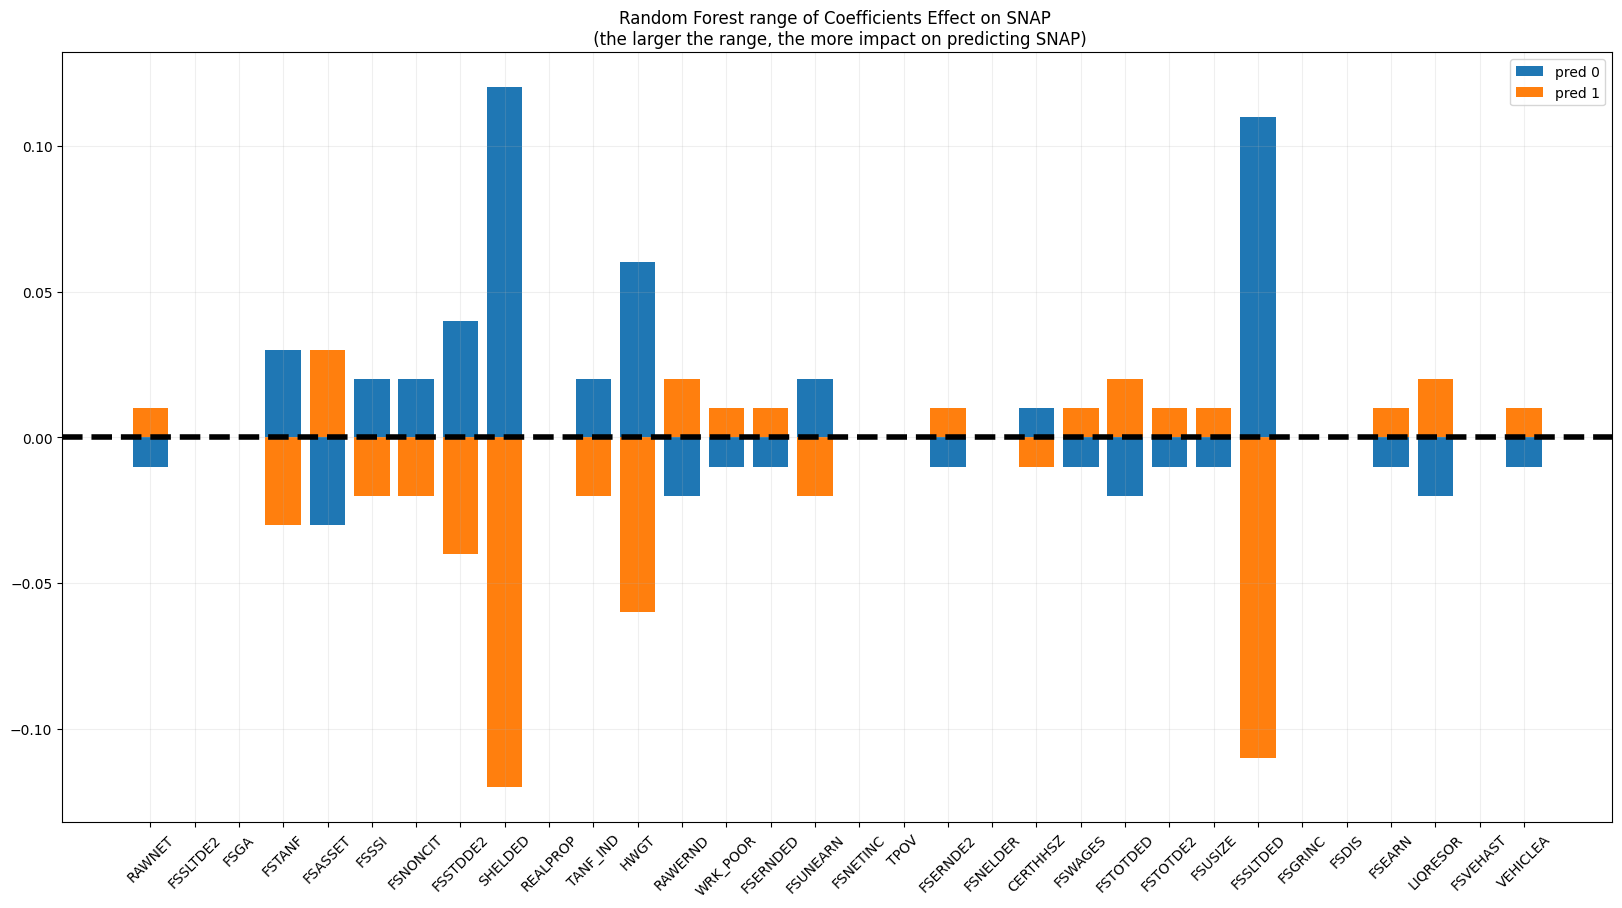

In [21]:
fig, ax = plt.subplots(figsize=(20,10))
plt.title('Random Forest range of Coefficients Effect on SNAP \n (the larger the range, the more impact on predicting SNAP)')
plt.grid(zorder=0,alpha = 0.2)
xs = np.arange(len(labels))
ax.bar(xs,coef_df['pred_0'], label = 'pred 0')
ax.bar(xs,coef_df['pred_1'],label = 'pred 1')
ax.axhline(y=0, linestyle='--', color='black', linewidth=4)
ax.set_xticks(coef_df.index)
ax.set_xticklabels(coef_df['feature'],rotation = 45)
plt.legend()
plt.savefig('./images/rf_corr.png');

In [22]:
# Extra Tree Classifier
et = ExtraTreeClassifier()
params={'max_depth':[None,3,4],
       'max_features':[None,'auto'],
       'max_leaf_nodes':[5,10]}
et_gs = GridSearchCV(et,param_grid=params)
et_gs.fit(X_train,y_train)
print(et_gs.best_score_)
et_gs.best_params_

0.8356349317958094


{'max_depth': None, 'max_features': None, 'max_leaf_nodes': 10}

In [23]:
# Bagging Classifier
bag = BaggingClassifier()
bag.fit(X_train,y_train)
y_pred_train = bag.predict(X_train)
y_pred_test = bag.predict(X_test)
print(f'cross_val_train = {np.mean(cross_val_score(model,X_train_pc,y_train,cv=4))}')
print(f'cross_val_test = {np.mean(cross_val_score(model,X_test_pc,y_test,cv=4))}')
print(f'test_recall = {recall_score(y_test, y_pred_test)}')
print(f'test_precision = {precision_score(y_test, y_pred_test)}')

cross_val_train = 0.7269399707174231
cross_val_test = 0.7133105802047782
test_recall = 0.952755905511811
test_precision = 0.9502617801047121


In [24]:
#Final Model
vote = VotingClassifier([
    ('rf',RandomForestClassifier(bootstrap=False,n_estimators=1000)),
    ('gb',GradientBoostingClassifier(max_depth=10,subsample=0.8)),
    ('bag',BaggingClassifier(n_estimators = 10))
])

vote.fit(X_train,y_train)

filename = 'final_model.sav'
pickle.dump(vote, open(filename, 'wb'))